In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### checking statistics

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### check missing value

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.shape

(7043, 21)

## The dataset contains telecom customer information including demographics, services subscribed, contract type, billing information, and churn status.

### churn distribution

In [7]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

C:\Users\jasir\AppData\Local\Temp\ipykernel_30804\266974229.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette={'No':'green','Yes':'red'})


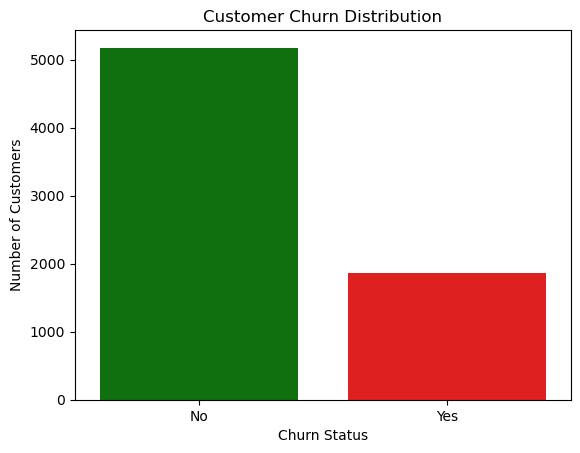

In [12]:
sns.countplot(x='Churn', data=df, palette={'No':'green','Yes':'red'})

plt.title("Customer Churn Distribution")

plt.xlabel("Churn Status")

plt.ylabel("Number of Customers")

plt.show()

### insight
From the chart, we can see that most customers are still using the company’s services, while a smaller portion have churned (left the company).
Approximately 73% of customers stayed, while around 26% of customers churned. This means nearly 1 out of every 4 customers stops using the service

### contract vs churn

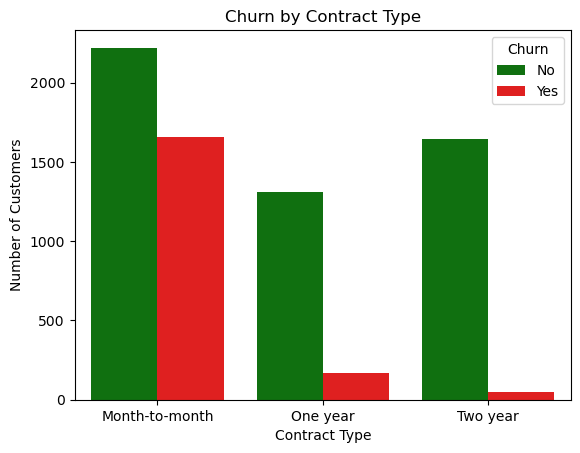

In [13]:
sns.countplot(x='Contract', hue='Churn', data=df,
              palette={'No':'green','Yes':'red'})

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

## insight
From the visualization, customers with month-to-month contracts show the highest churn rate compared to customers with longer-term contracts,longer term contracts are more likely to stay with the company.
This identifies that customers with flexible monthly plans may find it easier to leave the service.
Encouraging customers to move toward long-term contracts could help to reduce churn and improve customer commitment.

### Tenure vs Churn

C:\Users\jasir\AppData\Local\Temp\ipykernel_30804\1729401129.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df,


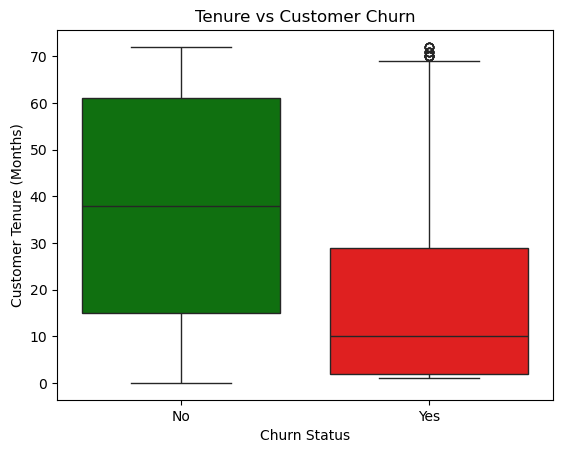

In [14]:
sns.boxplot(x='Churn', y='tenure', data=df,
            palette={'No':'green','Yes':'red'})

plt.title("Tenure vs Customer Churn")
plt.xlabel("Churn Status")
plt.ylabel("Customer Tenure (Months)")

plt.show()

### insight
Most of the churned customers have been with the company for only a few months, while customers who stayed generally have longer tenure.
This suggests that new customers are more likely to leave the service.This indicates that the first few months after a customer joins are very important.

### monthly charge vs churn

C:\Users\jasir\AppData\Local\Temp\ipykernel_30804\4135552419.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df,


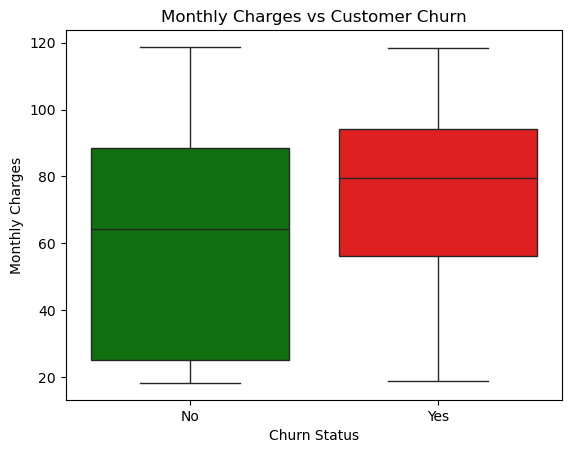

In [15]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
            palette={'No':'green','Yes':'red'})

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.show()

### insight
From the chart, we can see that customers who churn generally have higher monthly charges compared to customers who stay with the companyThis indicating that price may be one of the factors influencing customers to leave the service.
Needs to review the pricing strategy or service value,better packages,offers etc to reduce churn to improve customer satisfaction.

### internet vs churn

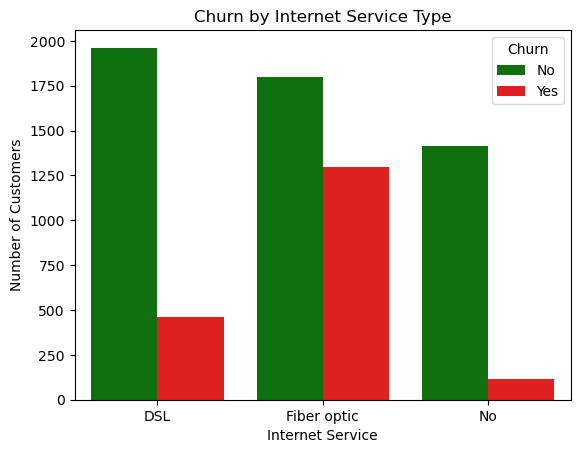

In [16]:
sns.countplot(x='InternetService', hue='Churn', data=df,
              palette={'No':'green','Yes':'red'})

plt.title("Churn by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

## insight
From the chart, we can observe that customers using fiber optic internet have a higher churn rate compared to customers using DSL,Customers who do not use internet service show relatively lower churn.
Indicate that fiber optic customers could be experiencing higher prices or service issues, which might be reason them to leave.

### customer churn rate

In [17]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
churn_rate

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### customer segmentation

In [19]:
df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Key Business insights 
1: Contract Type Impact
    Customers with month-to-month contracts have the highest churn rate, while customers     with one-year and two-year contracts are more likely to stay with the company. Long-     term contracts help improve customer retention.
2: Customer Tenure
    Customers with shorter tenure are more likely to churn. Most churned customers have      been with the company for only a few months. Long-term customers remain loyal.
3: Monthly Charges
    Customers paying higher monthly charges show a higher tendency to churn. This            suggests that pricing or perceived value may influence customer decisions.
4: Internet Service Type
    Customers using fiber optic internet have higher churn rates compared to DSL users.      Indicating possible pricing concerns or service issues with fiber plans.

### Business Recomendations
1: Encourage customers to move to long-term contracts by offering discounts or benefits.
2: Improve customer onboarding and engagement during the first few months to reduce         early churn.
3: Review pricing strategies for higher monthly charges and provide better value through    bundled services.
4: Improve service quality and support for fiber optic customers to increase                satisfaction.

In [20]:
df.to_csv("telco_churn_cleaned.csv", index=False)